# 08 — Joint Training: Detection + Lane Segmentation

**Goal:** Train a shared YOLO26 backbone/neck with both the native detection head and a lightweight lane segmentation head in a single stage.

## Architecture
```
Input → YOLO26 Backbone → Neck (FPN/PAN) → ┬→ Detect Head (10-class BDD boxes)
                                            └→ Lane Seg Head (binary mask)
```

## Colab Notes
- **GPU required:** T4 minimum (recommended: A100)
- **Training time:** ~2-4 hours for 10 epochs on full BDD100K with T4
- **Memory:** ~12+ GB GPU for yolo26s at batch=8, imgsz=640
- Uses **mixed precision (AMP)** for speed
- Uses **differential learning rates**: lower for pretrained backbone, higher for new lane head

### Prerequisites
Run these notebooks first:
- `02_bdd100k_preparation.ipynb` (detection labels)
- `07_prepare_lane_masks.ipynb` (lane masks)

## 1 — Setup

In [1]:
!pip install -q ultralytics>=8.4.0 opencv-python matplotlib pyyaml tqdm

In [2]:
import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"✅ GPU: {gpu} ({mem:.1f} GB)")
    if mem < 12:
        print("⚠️ Low GPU RAM. Reduce batch_size to 4 or use yolo26n.")
else:
    print("❌ No GPU! Joint training requires a GPU.")

✅ GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GB)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
LOCAL_DATASET_DIR = "/content/bdd100k_yolo"
os.makedirs(LOCAL_DATASET_DIR, exist_ok=True)

# ── 1. Restore images + labels from notebook 02's tar ─────────────
NB02_TAR = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo_nb02.tar")
if os.path.isfile(NB02_TAR):
    print(f"📦 Extracting images + labels from tar...")
    !tar -xf "{NB02_TAR}" -C {LOCAL_DATASET_DIR}
    print("✅ Images + labels restored")
else:
    print(f"❌ {NB02_TAR} not found! Run notebook 02 first.")

# ── 2. Restore masks from notebook 07's tar ───────────────────────
masks_dir = os.path.join(LOCAL_DATASET_DIR, "masks")
masks_tar = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo", "masks.tar")

if not os.path.isdir(masks_dir):
    if os.path.isfile(masks_tar):
        print("📦 Extracting masks...")
        !cp "{masks_tar}" /content/ && tar -xf /content/masks.tar -C /content/
        print("✅ Masks restored")
    else:
        raise FileNotFoundError(f"Missing: {masks_tar}")
else:
    print("✅ Masks already present")

# ── 3. Verify ─────────────────────────────────────────────────────
print("\n" + "="*50)
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val', 'masks/train', 'masks/val']:
    full = os.path.join(LOCAL_DATASET_DIR, sub)
    if os.path.isdir(full):
        print(f"  ✅ {sub}: {len(os.listdir(full)):,} files")
    else:
        print(f"  ❌ {sub}: MISSING")
print("="*50)


Mounted at /content/drive
📦 Extracting images + labels from tar...
✅ Images + labels restored
📦 Extracting masks...
✅ Masks restored

  ✅ images/train: 16,942 files
  ✅ images/val: 2,990 files
  ✅ labels/train: 16,942 files
  ✅ labels/val: 2,990 files
  ✅ masks/train: 16,942 files
  ✅ masks/val: 2,990 files


In [4]:
import os, sys, yaml

ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
DATASET_DIR = "/content/bdd100k_yolo"

# Add project src to path
PROJECT_SRC = os.path.join(ECOCAR_ROOT, "project", "src")
if os.path.isdir(PROJECT_SRC):
    sys.path.insert(0, os.path.dirname(PROJECT_SRC))

# Debug mode
DEBUG_LIMIT = None  # Set to 100 for quick test

if DEBUG_LIMIT:
    print(f"⚡ DEBUG MODE: {DEBUG_LIMIT} samples")

## 2 — Training Configuration

In [5]:
# ── Configuration ─────────────────────────────────────────────────
CONFIG = {
    # Model
    'pretrained_weights': 'yolo26s.pt',  # or yolo26n.pt for less memory
    'lane_hidden_channels': 64,
    'mask_height': 180,
    'mask_width': 320,

    # Dataset
    'train_images': os.path.join(DATASET_DIR, 'images', 'train'),
    'train_labels': os.path.join(DATASET_DIR, 'labels', 'train'),
    'train_masks':  os.path.join(DATASET_DIR, 'masks', 'train'),
    'val_images':   os.path.join(DATASET_DIR, 'images', 'val'),
    'val_labels':   os.path.join(DATASET_DIR, 'labels', 'val'),
    'val_masks':    os.path.join(DATASET_DIR, 'masks', 'val'),

    # Training
    'epochs': 10,
    'batch_size': 8,
    'img_size': 640,
    'lr': 1e-3,
    'weight_decay': 1e-4,

    # Training Stages (HybridNets/YOLOP Smooth Architecture)
    'stage1_epochs': 2,                 # Warmup: Detection-Prioritized
    'stage2_epochs': 3,                 # Ramp: Smooth Transition to Joint
    'stage1_det_weight': 1.0,
    'stage1_lane_weight': 0.0,          # Completely zeroed lane loss in Stage 1
    'stage2_det_weight': 1.0,           # Target stable detection weight
    'stage2_lane_weight': 0.5,          # Target stable lane weight

    # Performance
    'amp': True,
    'num_workers': 4,
    'save_period': 5,

    # Output
    'save_dir': os.path.join(ECOCAR_ROOT, 'training_runs', 'joint_det_lane'),
}

print("Joint Training Config:")
for k, v in CONFIG.items():
    print(f"  {k:<25} = {v}")

Joint Training Config:
  pretrained_weights        = yolo26s.pt
  lane_hidden_channels      = 64
  mask_height               = 180
  mask_width                = 320
  train_images              = /content/bdd100k_yolo/images/train
  train_labels              = /content/bdd100k_yolo/labels/train
  train_masks               = /content/bdd100k_yolo/masks/train
  val_images                = /content/bdd100k_yolo/images/val
  val_labels                = /content/bdd100k_yolo/labels/val
  val_masks                 = /content/bdd100k_yolo/masks/val
  epochs                    = 10
  batch_size                = 8
  img_size                  = 640
  lr                        = 0.001
  weight_decay              = 0.0001
  stage1_epochs             = 2
  stage2_epochs             = 3
  stage1_det_weight         = 1.0
  stage1_lane_weight        = 0.0
  stage2_det_weight         = 1.0
  stage2_lane_weight        = 0.5
  amp                       = True
  num_workers               = 4
  save_period 

## 3 — Build Multi-Task Model

In [6]:
try:
    from src.multitask_model import MultiTaskYOLO, build_multitask_model
    print("✅ Imported MultiTaskYOLO from src")
except ImportError:
    print("⚠️ Could not import from src, using inline definition")
    # See src/multitask_model.py for the full implementation
    # The inline version is abbreviated — copy multitask_model.py to Drive for best results
    raise ImportError(
        "Please upload the 'src/' folder to your Google Drive at "
        f"{os.path.dirname(PROJECT_SRC)}\n"
        "The multi-task model is too complex for inline definition."
    )

✅ Imported MultiTaskYOLO from src


In [7]:
# Build the multi-task model
model = build_multitask_model(
    weights=CONFIG['pretrained_weights'],
    lane_head_type='light_muster',
    lane_embed_dim=96,
    lane_num_heads=4,
    lane_depth=2,
    mask_height=CONFIG['mask_height'],
    mask_width=CONFIG['mask_width']
)

# Explicitly unfreeze all trainable parts
for p in model.backbone_neck.parameters():
    p.requires_grad = True

for p in model.detect_head.parameters():
    p.requires_grad = True

for p in model.lane_head.parameters():
    p.requires_grad = True

print("Backbone+Neck trainable:", sum(p.numel() for p in model.backbone_neck.parameters() if p.requires_grad))
print("Detect head trainable:", sum(p.numel() for p in model.detect_head.parameters() if p.requires_grad))
print("Lane head trainable:", sum(p.numel() for p in model.lane_head.parameters() if p.requires_grad))
print("Total trainable:", sum(p.numel() for p in model.parameters() if p.requires_grad))


import torch.nn as nn

print("type(model.detect_head):", type(model.detect_head))
print("is nn.Module:", isinstance(model.detect_head, nn.Module))

detect_params_all = sum(p.numel() for p in model.detect_head.parameters())
detect_params_trainable = sum(p.numel() for p in model.detect_head.parameters() if p.requires_grad)

print("Detect head total params:", detect_params_all)
print("Detect head trainable params:", detect_params_trainable)

print("Total model params:", sum(p.numel() for p in model.parameters()))


def count_params(module):
    return sum(p.numel() for p in module.parameters())

total = count_params(model)
det_params = count_params(model.detect_head)
lane_params = count_params(model.lane_head)
backbone_params = total - det_params - lane_params

print("\nParameter counts:")
print(f"  Backbone+Neck: {backbone_params:>12,}")
print(f"  Detect head:   {det_params:>12,}")
print(f"  Lane head:     {lane_params:>12,}")
print(f"  Total:         {total:>12,}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ MultiTaskYOLO built:
   Backbone+Neck layers: 23
   Detect head: Detect
   Neck output indices: [16, 19, 22]
   Neck channels: [128, 256, 512]
   Lane head params: 1,559,041
Backbone+Neck trainable: 9016000
Detect head trainable: 993784
Lane head trainable: 1559041
Total trainable: 11568825
type(model.detect_head): <class 'ultralytics.nn.modules.head.Detect'>
is nn.Module: True
Detect head total params: 993784
Detect head trainable params: 993784
Total model params: 11568825

Parameter counts:
  Backbone+Neck:    9,016,000
  Detect head:        993,784
  Lane head:        1,559,041
  Total:           11,568,825


## 4 — Create Joint Dataset

In [8]:
try:
    from src.joint_dataset import JointBDDDataset, joint_collate_fn
    print("✅ Imported JointBDDDataset from src")
except ImportError:
    raise ImportError("Please upload src/ to Drive. See instructions above.")

✅ Imported JointBDDDataset from src


In [9]:
import os

train_images = "/content/bdd100k_yolo/images/train"
train_labels = "/content/bdd100k_yolo/labels/train"
train_masks  = "/content/bdd100k_yolo/masks/train"

val_images = "/content/bdd100k_yolo/images/val"
val_labels = "/content/bdd100k_yolo/labels/val"
val_masks  = "/content/bdd100k_yolo/masks/val"

for d in [train_images, train_labels, train_masks, val_images, val_labels, val_masks]:
    print(d, "exists =", os.path.exists(d))
    if os.path.exists(d):
        print(" count =", len(os.listdir(d)))

/content/bdd100k_yolo/images/train exists = True
 count = 16942
/content/bdd100k_yolo/labels/train exists = True
 count = 16942
/content/bdd100k_yolo/masks/train exists = True
 count = 16942
/content/bdd100k_yolo/images/val exists = True
 count = 2990
/content/bdd100k_yolo/labels/val exists = True
 count = 2990
/content/bdd100k_yolo/masks/val exists = True
 count = 2990


In [10]:
import os

drive_train = "/content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo/images/train"
drive_val   = "/content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo/images/val"

print("Drive train exists:", os.path.exists(drive_train))
print("Drive val exists:", os.path.exists(drive_val))

if os.path.exists(drive_train):
    print("Drive train count:", len(os.listdir(drive_train)))
if os.path.exists(drive_val):
    print("Drive val count:", len(os.listdir(drive_val)))

Drive train exists: True
Drive val exists: True
Drive train count: 16629
Drive val count: 0


In [11]:
from torch.utils.data import DataLoader

# Train dataset
train_dataset = JointBDDDataset(
    images_dir=CONFIG['train_images'],
    labels_dir=CONFIG['train_labels'],
    masks_dir=CONFIG['train_masks'],
    img_size=CONFIG['img_size'],
    mask_height=CONFIG['mask_height'],
    mask_width=CONFIG['mask_width'],
    augment=True,
    debug_limit=DEBUG_LIMIT,
)

# Val dataset
val_dataset = JointBDDDataset(
    images_dir=CONFIG['val_images'],
    labels_dir=CONFIG['val_labels'],
    masks_dir=CONFIG['val_masks'],
    img_size=CONFIG['img_size'],
    mask_height=CONFIG['mask_height'],
    mask_width=CONFIG['mask_width'],
    augment=False,
    debug_limit=DEBUG_LIMIT,
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    collate_fn=joint_collate_fn,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    collate_fn=joint_collate_fn,
    pin_memory=True,
)

print(f"\nTrain: {len(train_dataset)} samples → {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples → {len(val_loader)} batches")

✅ JointBDDDataset: 16942 samples
   Images: /content/bdd100k_yolo/images/train
   Labels: /content/bdd100k_yolo/labels/train
   Masks:  /content/bdd100k_yolo/masks/train
✅ JointBDDDataset: 2990 samples
   Images: /content/bdd100k_yolo/images/val
   Labels: /content/bdd100k_yolo/labels/val
   Masks:  /content/bdd100k_yolo/masks/val

Train: 16942 samples → 2117 batches
Val:   2990 samples → 374 batches


## 5 — Sanity Check Batch

Images shape:     torch.Size([8, 3, 640, 640])
Det targets shape:torch.Size([115, 6])
Lane masks shape: torch.Size([8, 1, 180, 320])


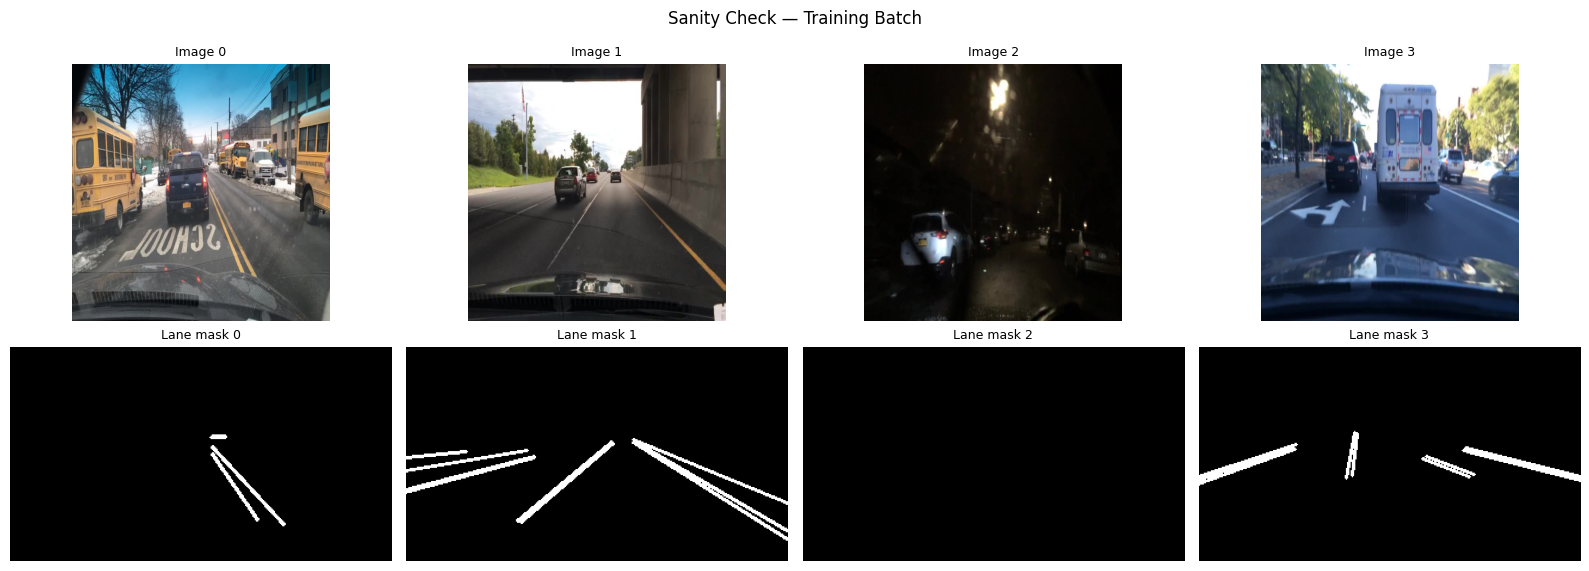

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Get one batch
batch = next(iter(train_loader))

print(f"Images shape:     {batch['images'].shape}")
print(f"Det targets shape:{batch['det_targets'].shape}")
print(f"Lane masks shape: {batch['lane_masks'].shape}")

# Show first 4 images with their lane masks
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i in range(min(4, batch['images'].shape[0])):
    img = batch['images'][i].permute(1, 2, 0).numpy()
    mask = batch['lane_masks'][i, 0].numpy()

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Image {i}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f'Lane mask {i}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Sanity Check — Training Batch', fontsize=12)
plt.tight_layout()
plt.show()

## 6 — Train!

In [13]:
try:
    from src.joint_trainer import JointTrainer, plot_joint_training_history
    print("✅ Imported JointTrainer from src")
except ImportError:
    raise ImportError("Please upload src/ to Drive.")

✅ Imported JointTrainer from src


In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

trainer = JointTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    det_loss_weight=CONFIG.get('stage2_det_weight', 1.0),
    lane_loss_weight=CONFIG.get('stage2_lane_weight', 0.5),
    stage1_epochs=CONFIG.get('stage1_epochs', 0),
    stage2_epochs=CONFIG.get('stage2_epochs', 0),
    stage1_det_weight=CONFIG.get('stage1_det_weight', 1.0),
    stage1_lane_weight=CONFIG.get('stage1_lane_weight', 0.0),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    device=device,
    amp=CONFIG['amp'],
    save_dir=CONFIG['save_dir'],
    save_period=CONFIG['save_period'],
)

/content/drive/MyDrive/EcoCAR/project/src/joint_trainer.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=amp)


✅ JointTrainer ready:
   Device: cuda
   AMP: True
   Staged Training: Yes (2 epochs stage 1)
   Backbone LR: 1.00e-04
   Detect head LR: 1.00e-03
   Lane head LR: 1.00e-03
   Save dir: /content/drive/MyDrive/EcoCAR/training_runs/joint_det_lane


In [15]:
# Start training
history = trainer.train(epochs=CONFIG['epochs'])


 Starting Joint Training — 10 epochs
\n************************************************************
 🔀 STAGE 1: DETECTION-PRIORITIZED WARMUP
    ↳ Det Weight:  1.000 | Lane Weight: 0.000
************************************************************\n
    ⚠️ Invalid gradient norm (nan). Auto-skipping optimizer step via Scaler.\n
    ⚠️ Invalid gradient norm (inf). Auto-skipping optimizer step via Scaler.\n
    ⚠️ Invalid gradient norm (inf). Auto-skipping optimizer step via Scaler.\n
    ⚠️ Invalid gradient norm (inf). Auto-skipping optimizer step via Scaler.\n
    ⚠️ Invalid gradient norm (inf). Auto-skipping optimizer step via Scaler.\n


/content/drive/MyDrive/EcoCAR/project/src/joint_trainer.py:360: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.amp):


Epoch   1/10 │ train: 17.4327 (det=17.4327, lane=1.7830) │ val: 16.3308 (det=16.3308, lane=1.8057) │ 99.5s
\n************************************************************
 🔀 STAGE 1: DETECTION-PRIORITIZED WARMUP
    ↳ Det Weight:  1.000 | Lane Weight: 0.000
************************************************************\n
    ⚠️ Invalid gradient norm (inf). Auto-skipping optimizer step via Scaler.\n
Epoch   2/10 │ train: 15.8313 (det=15.8313, lane=1.7817) │ val: 15.6686 (det=15.6686, lane=1.7680) │ 92.5s
\n************************************************************
 🔀 STAGE 2: SMOOTH TRANSITION RAMP (33%)
    ↳ Det Weight:  1.000 | Lane Weight: 0.167
************************************************************\n
Epoch   3/10 │ train: 15.3720 (det=15.2532, lane=0.7133) │ val: 15.5969 (det=15.4874, lane=0.6566) │ 90.9s
\n************************************************************
 🔀 STAGE 2: SMOOTH TRANSITION RAMP (67%)
    ↳ Det Weight:  1.000 | Lane Weight: 0.333
************************

## 7 — Training Results

💾 /content/drive/MyDrive/EcoCAR/training_runs/joint_det_lane/training_curves.png


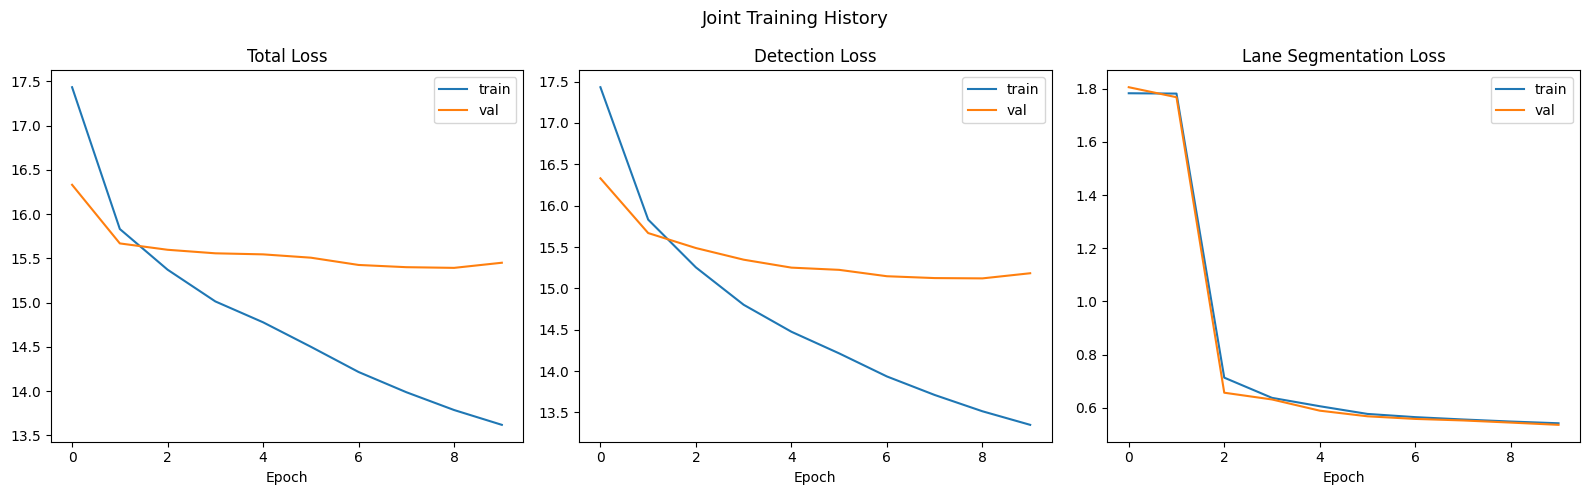

In [16]:
# Plot training curves
save_path = os.path.join(CONFIG['save_dir'], 'training_curves.png')
plot_joint_training_history(history, save_path=save_path)

In [17]:
# Show saved weights
weights_dir = os.path.join(CONFIG['save_dir'], 'weights')
if os.path.isdir(weights_dir):
    print("\nSaved weights:")
    for f in sorted(os.listdir(weights_dir)):
        size_mb = os.path.getsize(os.path.join(weights_dir, f)) / (1024**2)
        print(f"  {f} ({size_mb:.1f} MB)")


Saved weights:
  best.pt (129.4 MB)
  checkpoint.pt (129.5 MB)
  last.pt (129.4 MB)


## 8 — Backup Best Weights

In [18]:
import shutil

best_src = os.path.join(weights_dir, 'best.pt')
backup_dir = os.path.join(ECOCAR_ROOT, 'weights')
os.makedirs(backup_dir, exist_ok=True)

if os.path.isfile(best_src):
    dst = os.path.join(backup_dir, 'joint_det_lane_best.pt')
    shutil.copy2(best_src, dst)
    print(f"✅ Best weights backed up: {dst}")
    print(f"\n📌 Use this path in notebook 09:")
    print(f"   {dst}")

✅ Best weights backed up: /content/drive/MyDrive/EcoCAR/weights/joint_det_lane_best.pt

📌 Use this path in notebook 09:
   /content/drive/MyDrive/EcoCAR/weights/joint_det_lane_best.pt


In [19]:
print("\n" + "="*60)
print(" JOINT TRAINING — COMPLETE")
print("="*60)
print(f" Model:          {CONFIG['pretrained_weights']} + LaneSegHead")
print(f" Epochs:         {CONFIG['epochs']}")
print(f" Stage 1 config: {CONFIG.get('stage1_epochs')} epochs (Det: {CONFIG.get('stage1_det_weight')}, Lane: {CONFIG.get('stage1_lane_weight')})")
print(f" Stage 2 config: Det: {CONFIG.get('stage2_det_weight')}, Lane: {CONFIG.get('stage2_lane_weight')}")
print(f" Outputs:        {CONFIG['save_dir']}")
print("="*60)
print("\n🎯 Proceed to notebook 09 for joint inference!")


 JOINT TRAINING — COMPLETE
 Model:          yolo26s.pt + LaneSegHead
 Epochs:         10
 Stage 1 config: 2 epochs (Det: 1.0, Lane: 0.0)
 Stage 2 config: Det: 1.0, Lane: 0.5
 Outputs:        /content/drive/MyDrive/EcoCAR/training_runs/joint_det_lane

🎯 Proceed to notebook 09 for joint inference!
